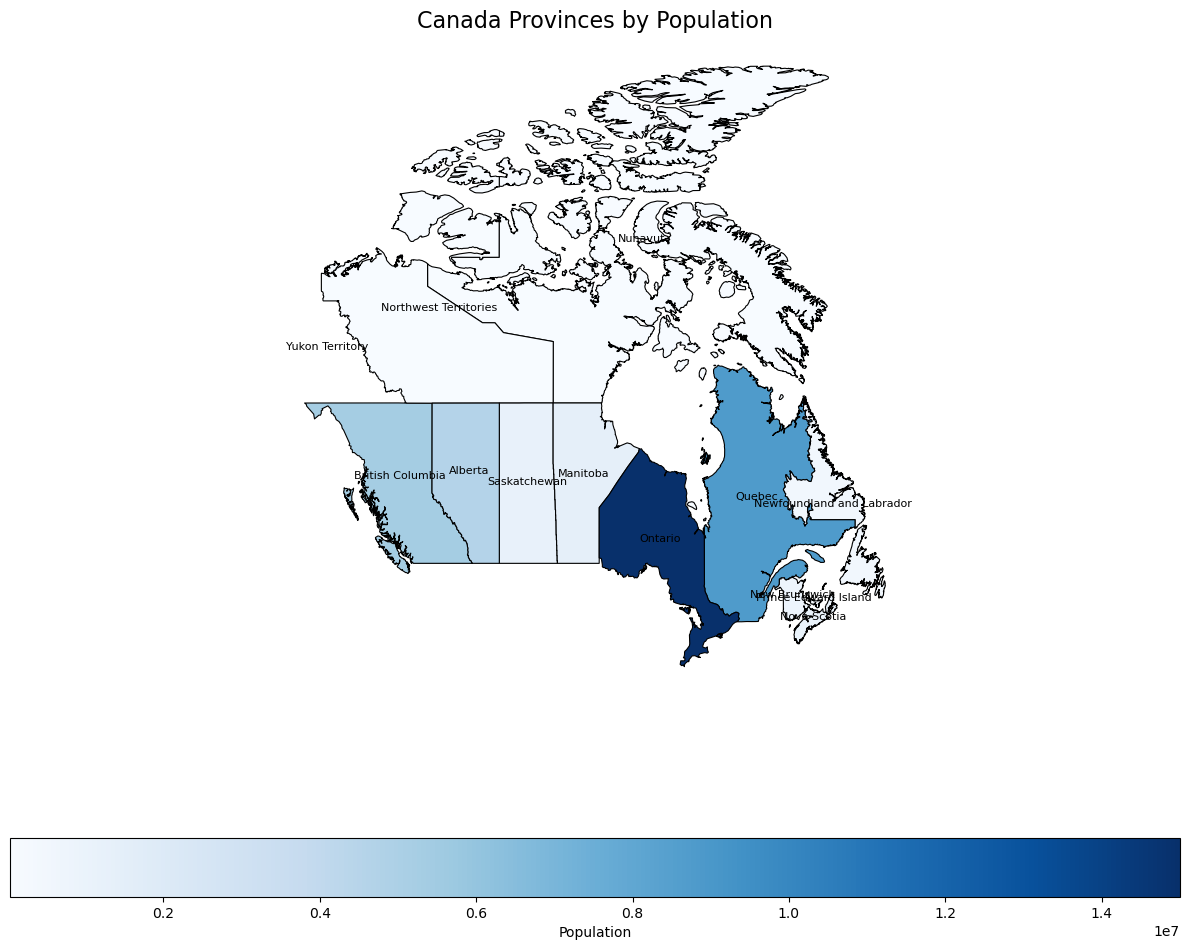

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Canada provinces map
# -----------------------------
# GeoJSON source (StatCan simplified boundaries)
url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/canada.geojson"
canada = gpd.read_file(url)

# -----------------------------
# 2. Create key metrics dataset
# -----------------------------
# Population (approx recent values)
data = {
    "name": [
        "Alberta", "British Columbia", "Manitoba", "New Brunswick",
        "Newfoundland and Labrador", "Nova Scotia", "Ontario",
        "Prince Edward Island", "Quebec", "Saskatchewan",
        "Northwest Territories", "Nunavut", "Yukon"
    ],
    "population": [
        4600000, 5300000, 1400000, 800000,
        520000, 1000000, 15000000,
        180000, 8800000, 1200000,
        45000, 40000, 45000
    ]
}

df = pd.DataFrame(data)

# -----------------------------
# 3. Merge data with map
# -----------------------------
merged = canada.merge(df, on="name", how="left")

# -----------------------------
# 4. Plot choropleth
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged.plot(
    column="population",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Population", "orientation": "horizontal"},
    ax=ax
)

# -----------------------------
# 5. Add labels (province names)
# -----------------------------
for idx, row in merged.iterrows():
    if row["geometry"] is not None:
        centroid = row["geometry"].centroid
        ax.text(
            centroid.x, centroid.y,
            row["name"],
            fontsize=8,
            ha='center'
        )

# -----------------------------
# 6. Styling
# -----------------------------
ax.set_title("Canada Provinces by Population", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()